In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Estadística avanzada (te lo van a pedir después)
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 👇 IMPORTANTE: usamos TU conexión, no engine
from scripts.load_to_postgres import conectar

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías listas")

✅ Librerías listas


In [2]:
# ── CELDA 2: Cargar datos desde PostgreSQL ────────────────────

conn = conectar()

query = """
SELECT
    name,
    capital,
    region,
    subregion,
    population,
    area,
    latitude,
    longitude,
    density,
    fecha_extraccion
FROM countries
"""

df = pd.read_sql(query, conn)

conn.close()

print("✅ Datos cargados correctamente")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

✅ Datos cargados correctamente
Filas: 246
Columnas: 10


/tmp/ipykernel_42534/3327327372.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,name,capital,region,subregion,population,area,latitude,longitude,density,fecha_extraccion
0,Ivory Coast,Yamoussoukro,Africa,Western Africa,31719275,322463.0,8.000000,-5.000000,98.365626,2026-04-14 16:56:47.771989
1,Italy,Rome,Europe,Southern Europe,58927633,301336.0,42.833333,12.833333,195.554574,2026-04-14 16:56:47.772016
2,Kyrgyzstan,Bishkek,Asia,Central Asia,7281800,199951.0,41.000000,75.000000,36.417922,2026-04-14 16:56:47.772023
3,Papua New Guinea,Port Moresby,Oceania,Melanesia,11781559,462840.0,-6.000000,147.000000,25.454928,2026-04-14 16:56:47.772027
4,Fiji,Suva,Oceania,Melanesia,900869,18272.0,-17.713400,178.065000,49.303251,2026-04-14 16:56:47.772032


In [3]:
# ── CELDA 3: Inspección del dataset ──────────────────────────

print("=" * 50)
print("INFO DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos:")
print(df.isnull().sum())

# 🔍 NUEVO: verificar valores en 0
print("\n⚠️ Valores en 0:")
print("Population =", (df['population'] == 0).sum())
print("Area       =", (df['area'] == 0).sum())
print("Density    =", (df['density'] == 0).sum())

print("\n🌍 Regiones:")
print(df['region'].value_counts())

INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              246 non-null    str           
 1   capital           246 non-null    str           
 2   region            246 non-null    str           
 3   subregion         246 non-null    str           
 4   population        246 non-null    int64         
 5   area              246 non-null    float64       
 6   latitude          246 non-null    float64       
 7   longitude         246 non-null    float64       
 8   density           246 non-null    float64       
 9   fecha_extraccion  246 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1), str(4)
memory usage: 28.3 KB
None

📊 Valores nulos:
name                0
capital             0
region              0
subregion           0
population          0
area                0
latitude    

In [4]:
# ── CELDA: Limpieza de datos ─────────────────

df = df[df['population'] > 0]

print("✅ Datos limpiados")
print(f"Filas restantes: {df.shape[0]}")

✅ Datos limpiados
Filas restantes: 243


In [5]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

vars_num = ['population', 'area', 'density', 'latitude', 'longitude']

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
         population         area   density  latitude  longitude
count  2.430000e+02       243.00    243.00    243.00     243.00
mean   3.299921e+07    560721.09    355.43     17.78      12.95
std    1.337468e+08   1735314.91   1468.62     25.23      74.07
min    3.500000e+01         0.49      0.03    -51.75    -176.20
25%    3.066275e+05      1745.00     31.71      1.71     -55.50
50%    5.413813e+06     69700.00     89.76     16.75      17.00
75%    2.124872e+07    388490.50    238.33     39.25      47.75
max    1.417492e+09  17098246.00  19021.29     78.00     178.06


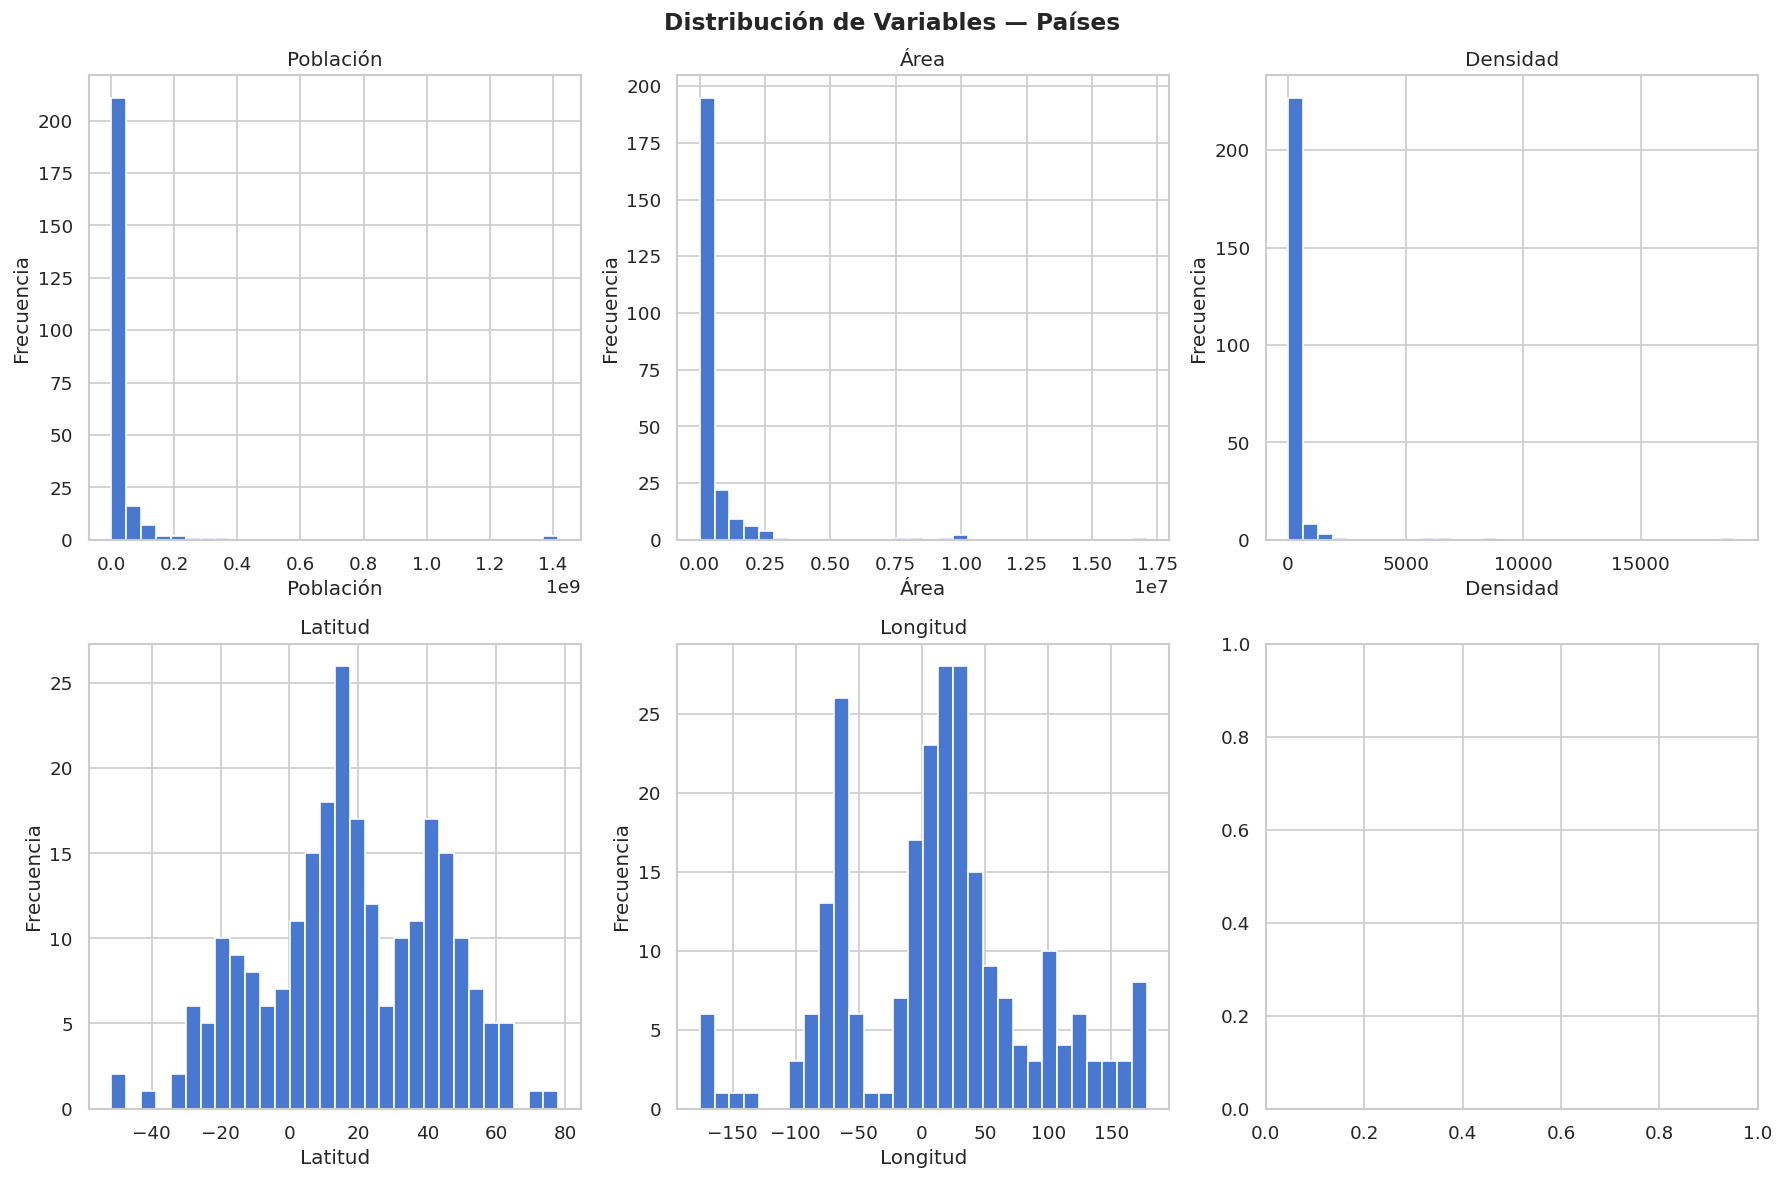

In [6]:
# ── CELDA 5: Distribución de variables ─────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribución de Variables — Países',
             fontsize=14, fontweight='bold')

datos = [
    ('population', 'Población'),
    ('area', 'Área'),
    ('density', 'Densidad'),
    ('latitude', 'Latitud'),
    ('longitude', 'Longitud')
]

for ax, (col, label) in zip(axes.flat, datos):
    ax.hist(df[col], bins=30, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [7]:
# ── CELDA 6: Transformación log ─────────────────────────

import numpy as np

df['log_population'] = np.log(df['population'] + 1)
df['log_area'] = np.log(df['area'] + 1)
df['log_density'] = np.log(df['density'] + 1)

print("✅ Variables log creadas")
df[['population', 'log_population']].head()

✅ Variables log creadas


,population,log_population
0,31719275,17.272435
1,58927633,17.891821
2,7281800,15.800889
3,11781559,16.282046
4,900869,13.711116


In [8]:
# ── CELDA NT: Estadísticas con transformación log ─────────────

vars_log = ['log_population', 'log_area', 'log_density']

desc_log = df[vars_log].describe().round(2)

print("📊 ESTADÍSTICAS CON LOG")
print(desc_log)

📊 ESTADÍSTICAS CON LOG
       log_population  log_area  log_density
count          243.00    243.00       243.00
mean            14.64     10.27         4.46
std              3.08      3.42         1.57
min              3.58      0.40         0.03
25%             12.63      7.46         3.49
50%             15.50     11.15         4.51
75%             16.87     12.87         5.48
max             21.07     16.65         9.85


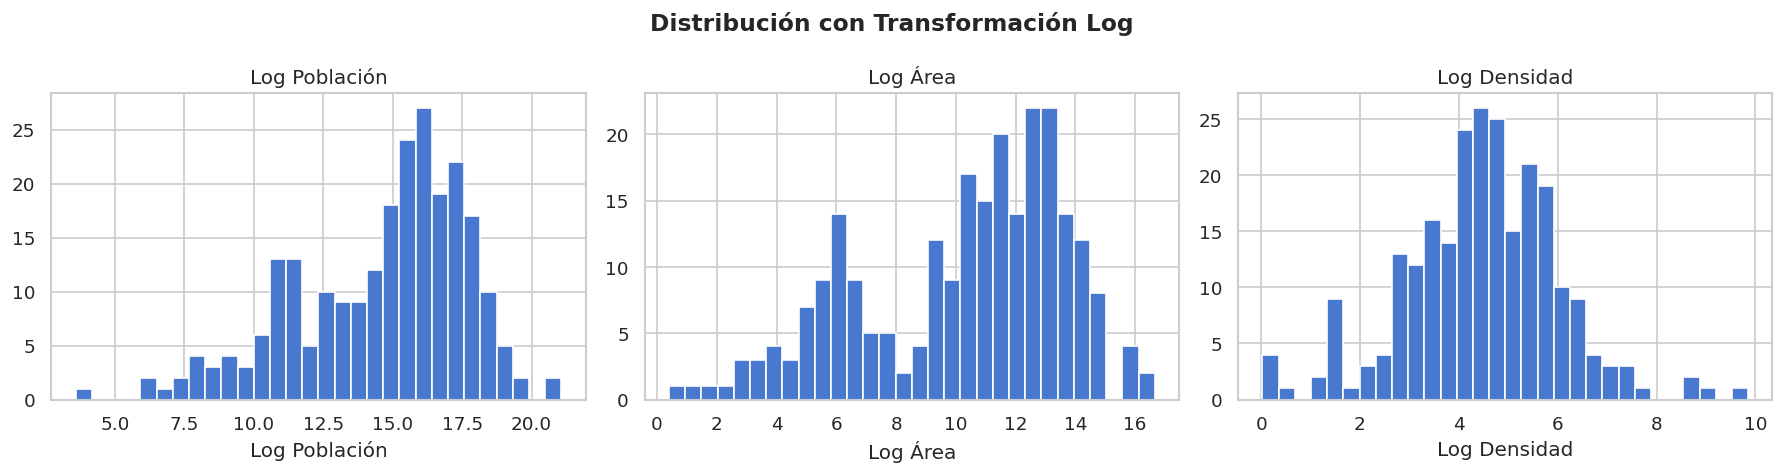

In [9]:
# ── CELDA 6: Distribución con log ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución con Transformación Log',
             fontsize=14, fontweight='bold')

datos_log = [
    ('log_population', 'Log Población'),
    ('log_area', 'Log Área'),
    ('log_density', 'Log Densidad')
]

for ax, (col, label) in zip(axes, datos_log):
    ax.hist(df[col], bins=30, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel(label)

plt.tight_layout()
plt.show()

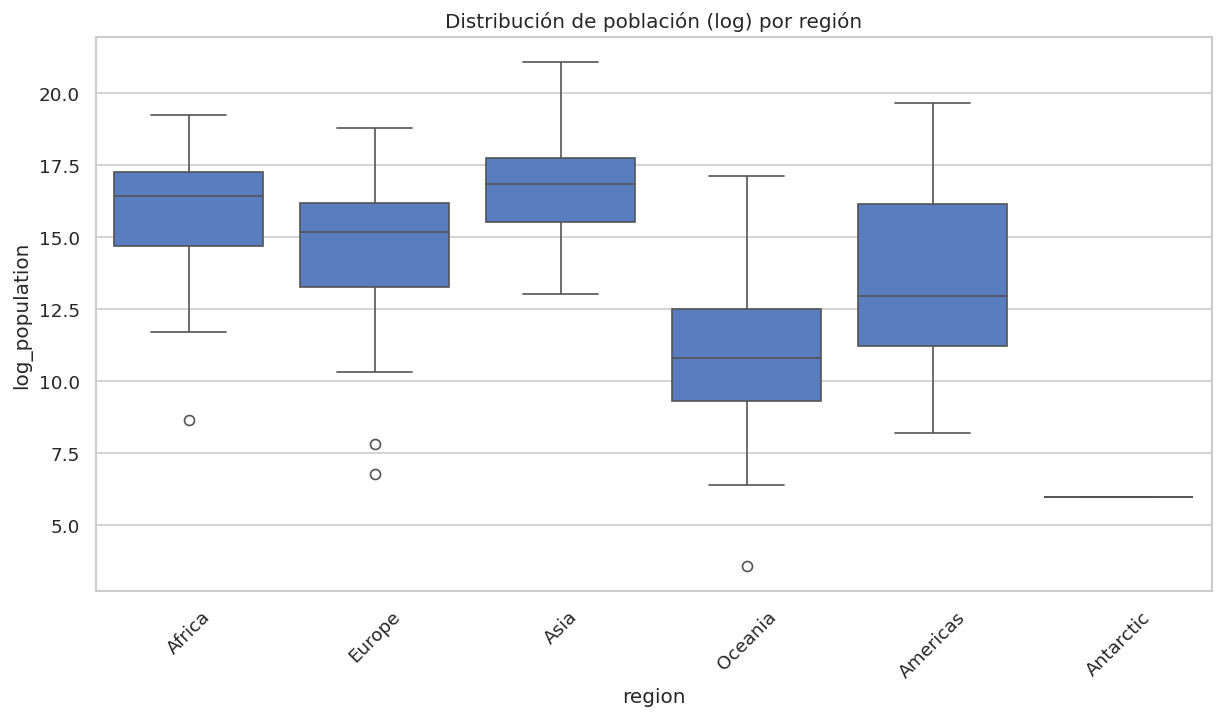

In [10]:
# ── CELDA 7: Boxplot por región (log) ─────────────────────

plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='region', y='log_population')
plt.xticks(rotation=45)
plt.title("Distribución de población (log) por región")

plt.show()

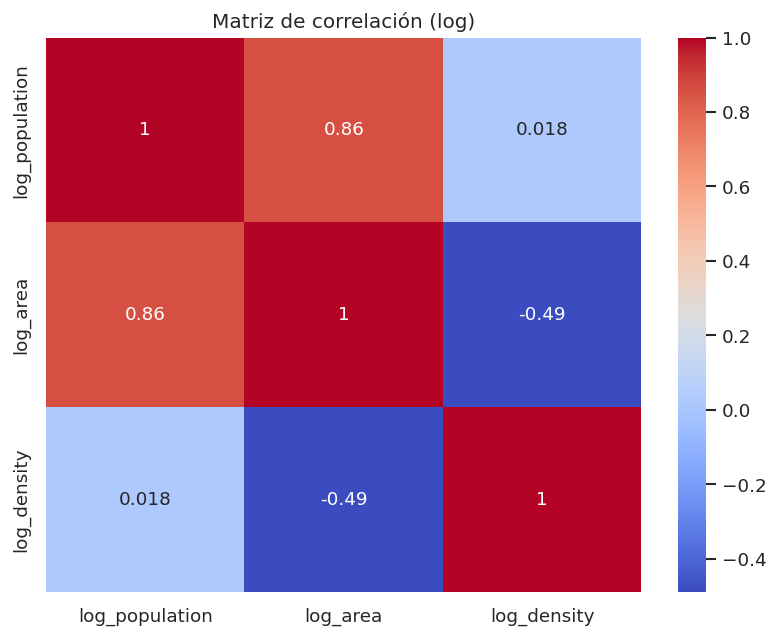


📊 MATRIZ COMPLETA:
                log_population  log_area  log_density
log_population           1.000     0.858        0.018
log_area                 0.858     1.000       -0.489
log_density              0.018    -0.489        1.000


In [11]:
# ── CELDA 7: Matriz de correlación (COMPLETA) ─────────────

vars_log = ['log_population', 'log_area', 'log_density']

corr = df[vars_log].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Matriz de correlación (log)")
plt.show()

print("\n📊 MATRIZ COMPLETA:")
print(corr.round(3))

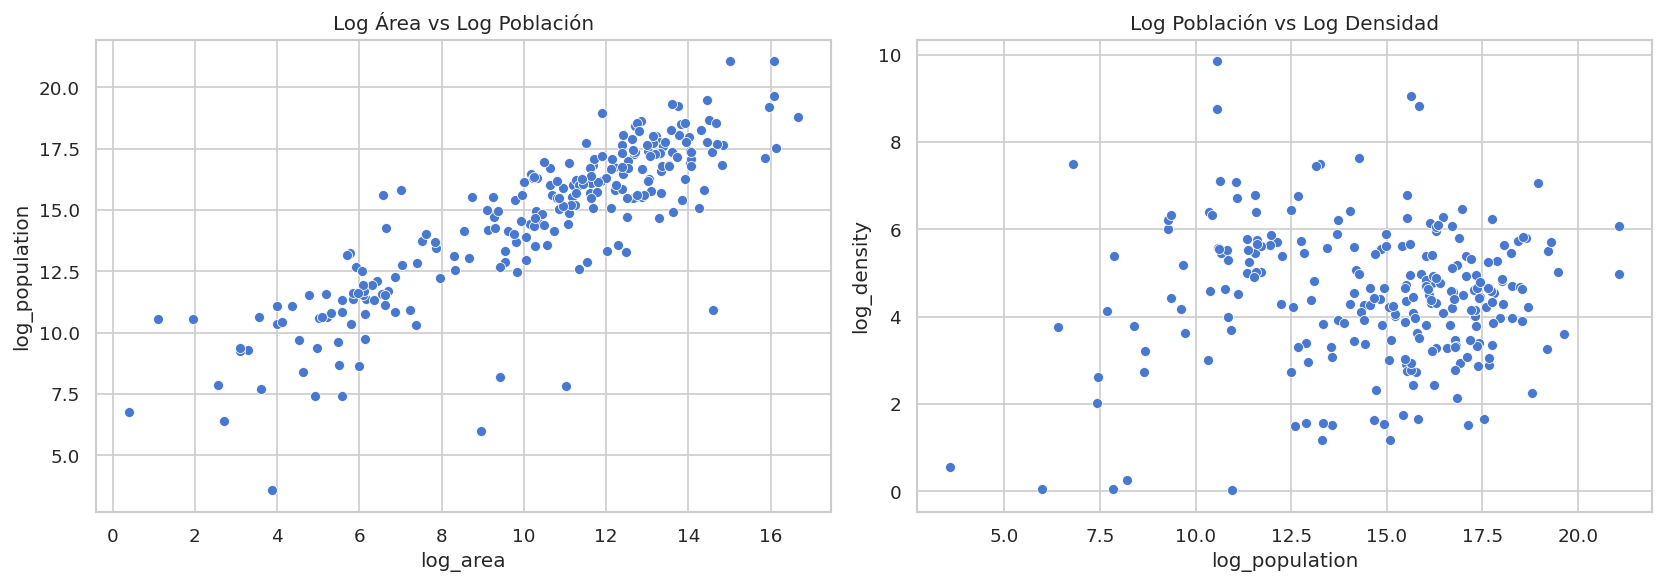

In [12]:
# ── CELDA 8: Relaciones (CON LOG) ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(x='log_area', y='log_population', data=df, ax=axes[0])
axes[0].set_title("Log Área vs Log Población")


sns.scatterplot(x='log_population', y='log_density', data=df, ax=axes[1])
axes[1].set_title("Log Población vs Log Densidad")

plt.tight_layout()
plt.show()

In [13]:
# ── CELDA 9: Regresión simple (CORRECTO) ─────────────────

X = df[['log_area']].values   # 👈 SOLO UNA VARIABLE
y = df['log_density'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Datos divididos correctamente")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test : {X_test.shape[0]} muestras")

✅ Datos divididos correctamente
Train: 194 muestras
Test : 49 muestras


In [14]:
# ── CELDA 10: Modelo simple ─────────────────────────

from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto β₀: {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁: {modelo_simple.coef_[0]:.4f}")

print("\nEcuación:")
print(f"log_density = {modelo_simple.intercept_:.3f} + {modelo_simple.coef_[0]:.3f} * log_area")

Intercepto β₀: 6.6723
Coeficiente β₁: -0.2229

Ecuación:
log_density = 6.672 + -0.223 * log_area


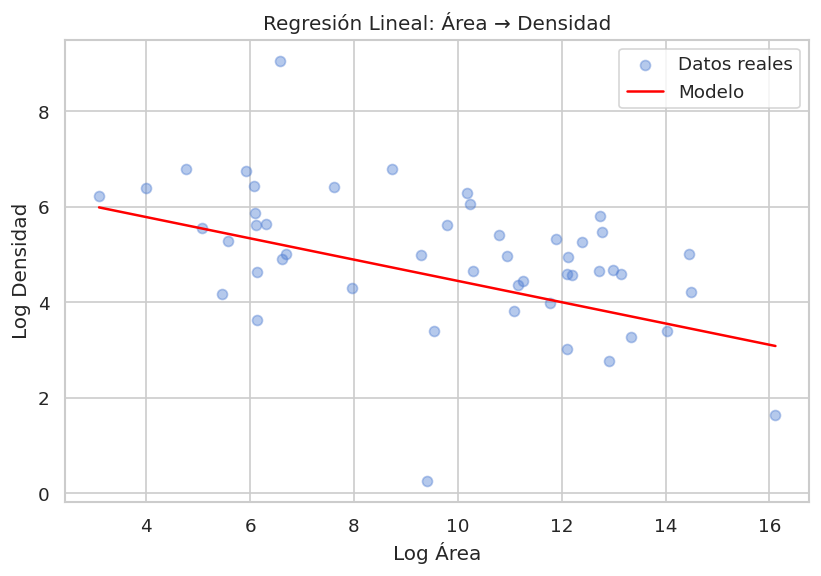

In [15]:
# ── CELDA 11: Visualización correcta ─────────────────────

plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, alpha=0.4, label="Datos reales")

# ordenar para que la línea se vea bien
orden = X_test[:,0].argsort()
plt.plot(X_test[orden], y_pred_simple[orden], color='red', label="Modelo")

plt.xlabel("Log Área")
plt.ylabel("Log Densidad")
plt.title("Regresión Lineal: Área → Densidad")

plt.legend()
plt.show()

In [16]:
# ── CELDA 12: Evaluación del modelo ─────────────────────────

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)

print("=" * 40)
print("📊 MÉTRICAS DEL MODELO")
print("=" * 40)
print(f"R²   (explicación del modelo): {r2:.4f}")
print(f"MSE  (error cuadrático)      : {mse:.4f}")
print(f"RMSE (error promedio)        : {rmse:.4f}")
print(f"MAE  (error absoluto)        : {mae:.4f}")
print("=" * 40)

📊 MÉTRICAS DEL MODELO
R²   (explicación del modelo): 0.1512
MSE  (error cuadrático)      : 1.6977
RMSE (error promedio)        : 1.3029
MAE  (error absoluto)        : 0.9975


In [17]:
# ── CELDA 13: OLS correcto ─────────────────────────

import statsmodels.api as sm

X_ols = sm.add_constant(df['log_area'])   # 👈 variable correcta
modelo_ols_simple = sm.OLS(df['log_density'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:            log_density   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     75.68
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           5.30e-16
Time:                        11:52:55   Log-Likelihood:                -420.63
No. Observations:                 243   AIC:                             845.3
Df Residuals:                     241   BIC:                             852.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7698      0.279     24.239      0.0

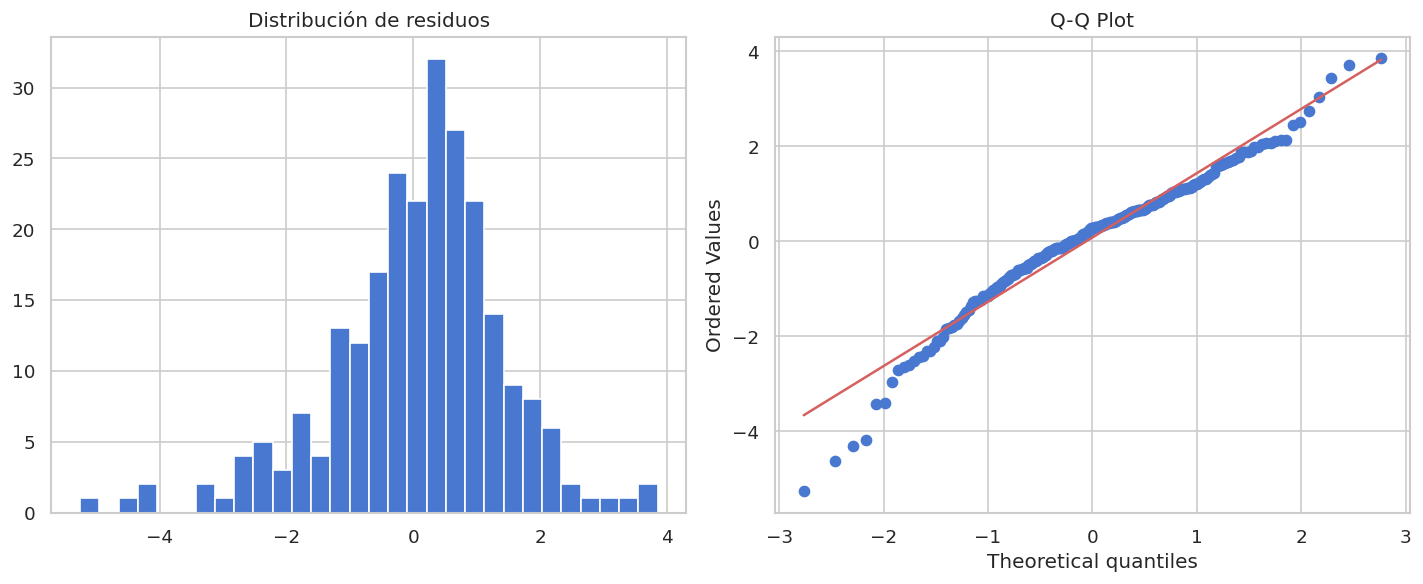

p-value: 0.00001
⚠️ Residuos NO normales


In [18]:
# ── CELDA 14: Normalidad de residuos ─────────────────────────

# Predicción sobre TODO el dataset (con la variable correcta)
y_pred_all = modelo_simple.predict(df[['log_area']].values)

# Residuos correctos
residuos = df['log_density'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histograma
axes[0].hist(residuos, bins=30, edgecolor='white')
axes[0].set_title("Distribución de residuos")

# Q-Q Plot
from scipy import stats
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

# Test Shapiro-Wilk
stat, p = stats.shapiro(residuos)

print(f"p-value: {p:.5f}")

if p > 0.05:
    print("✅ Residuos normales")
else:
    print("⚠️ Residuos NO normales")

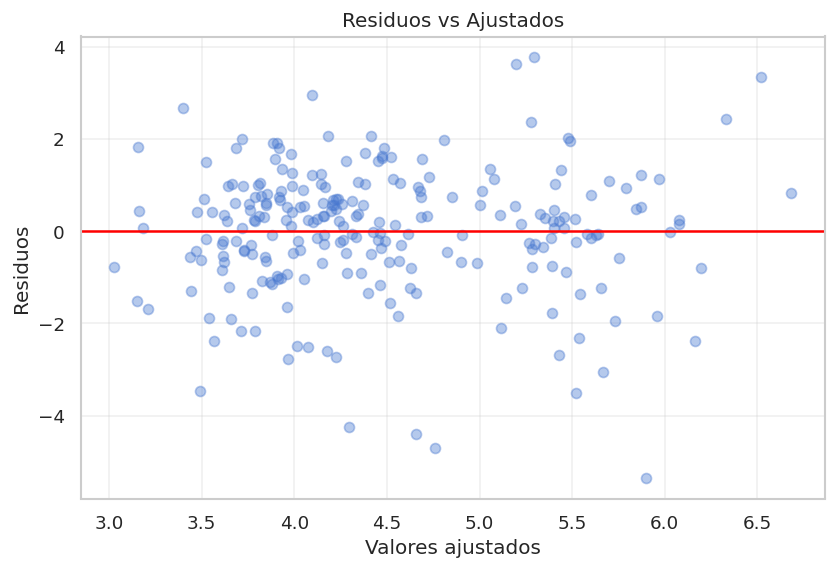

p-value: 0.02241
⚠️ Heterocedasticidad


In [19]:
# ── CELDA 15: Homocedasticidad ─────────────────────────────

residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(8,5))

plt.scatter(ajustados_ols, residuos_ols, alpha=0.4)
plt.axhline(0, color='red')

plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Ajustados")

plt.grid(alpha=0.3)
plt.show()

# Test Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print(f"p-value: {lm_p:.5f}")

if lm_p > 0.05:
    print("✅ Homocedasticidad")
else:
    print("⚠️ Heterocedasticidad")

In [20]:
# ── CELDA 16: Modelo múltiple (adaptado) ─────────────────

FEATURES = ['log_area', 'log_population']

X_multi = df[FEATURES].values
y = df['log_density'].values

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto β₀: {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"{feat}: {coef:.4f}")

Intercepto β₀: 1.1985
log_area: -0.8701
log_population: 0.8328


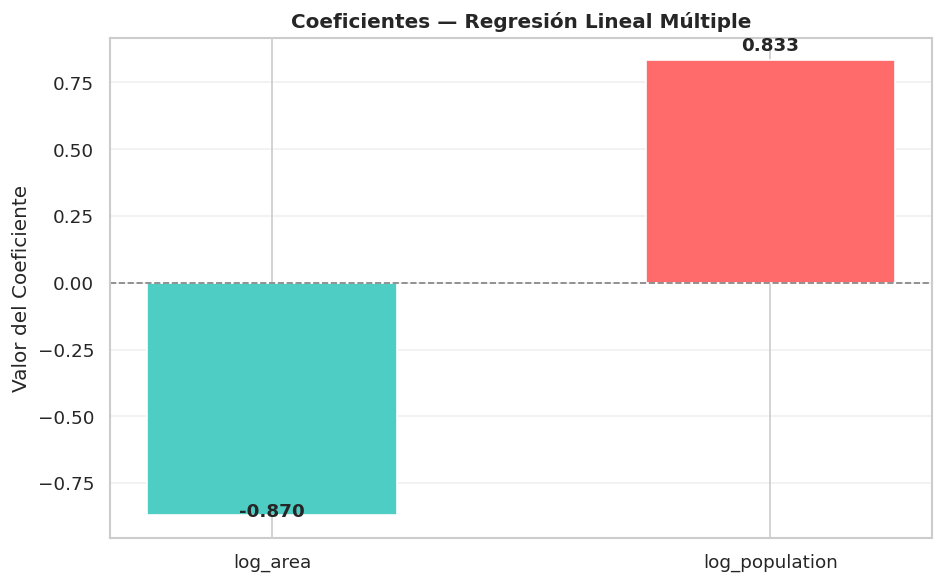

In [21]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.02 if coef >= 0 else -0.02
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

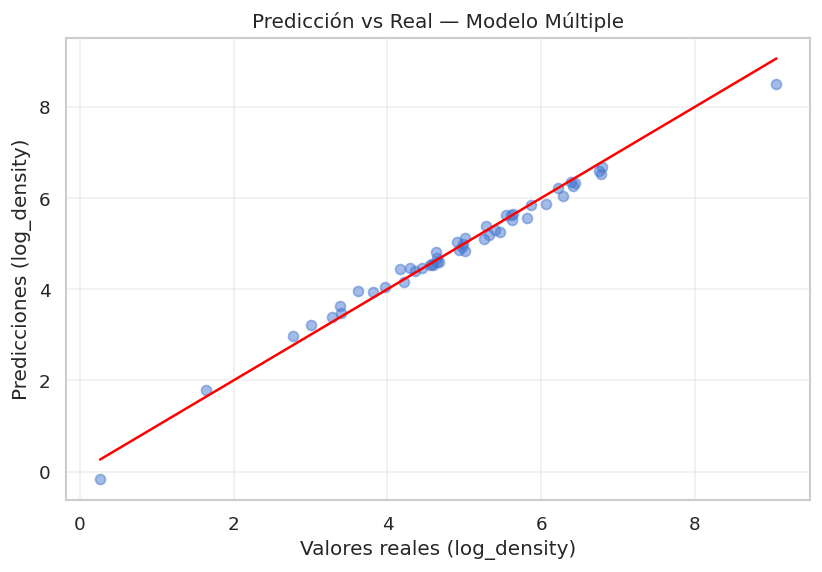

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(y_test_m, y_pred_multi, alpha=0.5)
plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    color='red'
)

plt.xlabel("Valores reales (log_density)")
plt.ylabel("Predicciones (log_density)")
plt.title("Predicción vs Real — Modelo Múltiple")

plt.grid(alpha=0.3)
plt.show()

In [23]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"R²   : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"MSE  : {mse_m:.4f}")
print(f"RMSE : {rmse_m:.4f}")
print(f"MAE  : {mae_m:.4f}")
print("=" * 48)

📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
R²   : 0.9850  (98.50%)
MSE  : 0.0299
RMSE : 0.1730
MAE  : 0.1343


In [24]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────

import statsmodels.api as sm

X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['log_density'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:            log_density   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     3227.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          3.49e-174
Time:                        11:52:56   Log-Likelihood:                -49.416
No. Observations:                 243   AIC:                             104.8
Df Residuals:                     240   BIC:                             115.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.1296      0.101     11.

In [25]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
    if v < 5 else (
        "⚠️ Moderada (5 ≤ VIF < 10)"
        if v < 10 else
        "❌ Severa (VIF ≥ 10)"
    )
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
      Variable    VIF            Criterio
      log_area 32.222 ❌ Severa (VIF ≥ 10)
log_population 32.222 ❌ Severa (VIF ≥ 10)


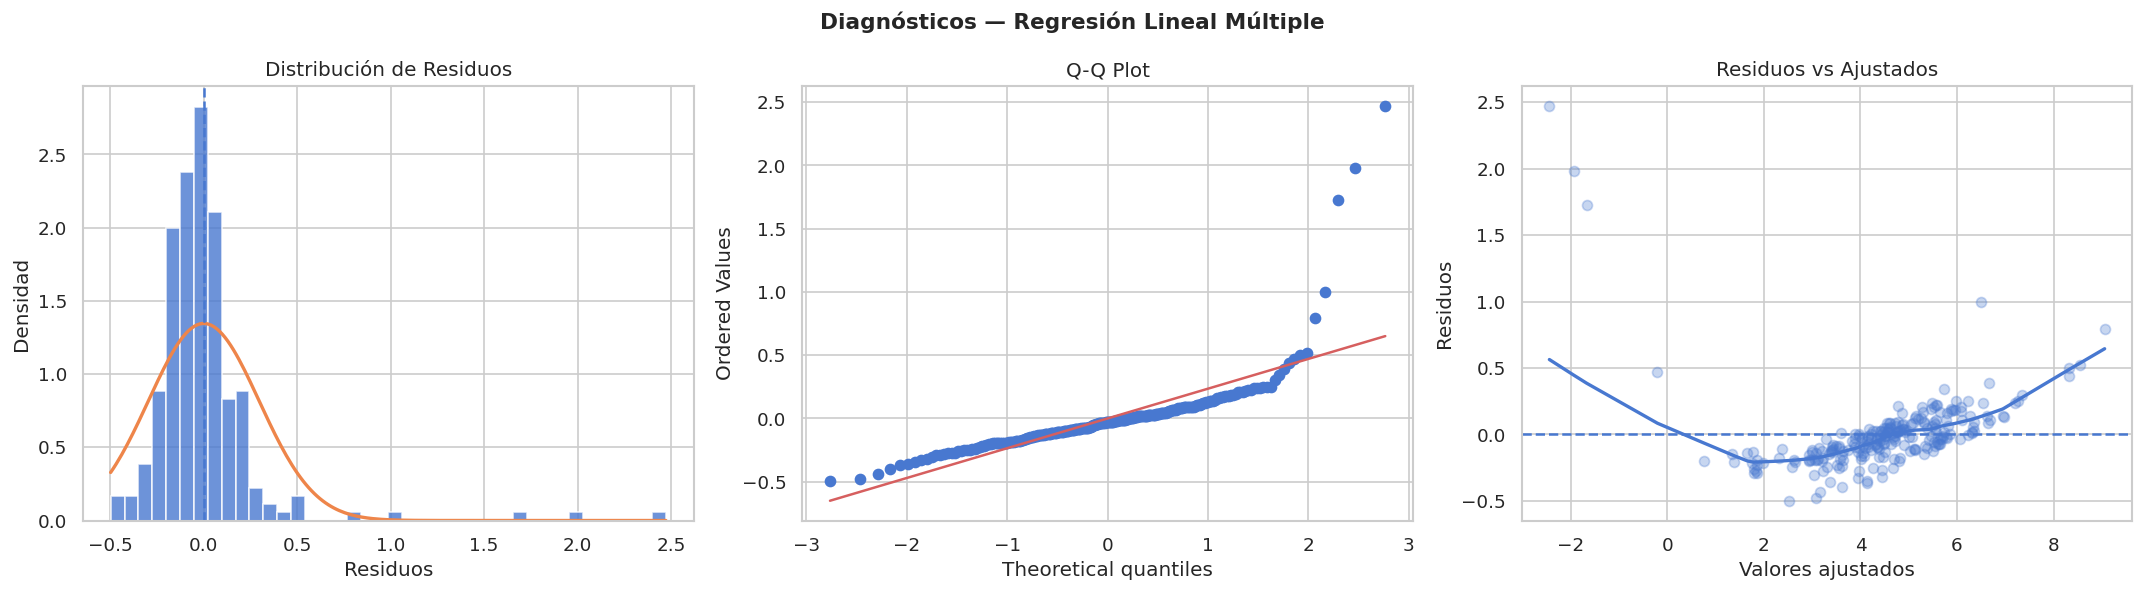


🔬 Test Shapiro-Wilk (Normalidad):
p-value: 0.000000
Resultado: ⚠️ No normal

🔬 Test Breusch-Pagan (Homocedasticidad):
p-value: 0.000000
Resultado: ⚠️ Heterocedasticidad


In [26]:
# ── CELDA 21: Diagnósticos — modelo múltiple ─────────────────

import numpy as np
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan

# Residuos y valores ajustados
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

# ── 1. Histograma de residuos
axes[0].hist(residuos_m, bins=40, edgecolor='white', density=True, alpha=0.8)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             linewidth=2)
axes[0].axvline(0, linestyle='--')
axes[0].set_title('Distribución de Residuos')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')

# ── 2. Q-Q Plot
stats.probplot(residuos_m, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

# ── 3. Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.3)
axes[2].axhline(0, linestyle='--')

lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1], linewidth=2)

axes[2].set_title('Residuos vs Ajustados')
axes[2].set_xlabel('Valores ajustados')
axes[2].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

# ── Tests estadísticos

# Shapiro-Wilk (normalidad)
stat_sw_m, p_sw_m = stats.shapiro(residuos_m)

# Breusch-Pagan (homocedasticidad)
lm_m, lm_p_m, _, _ = het_breuschpagan(
    residuos_m,
    modelo_ols_multi.model.exog
)

print("\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"p-value: {p_sw_m:.6f}")
print("Resultado:", "✅ Normal" if p_sw_m > 0.05 else "⚠️ No normal")

print("\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"p-value: {lm_p_m:.6f}")
print("Resultado:", "✅ Homocedasticidad" if lm_p_m > 0.05 else "⚠️ Heterocedasticidad")

In [27]:
# ── CELDA 22: Comparación final (formato presentación) ───────

print("\n" + "="*70)
print("📊 COMPARACIÓN DE MODELOS")
print("="*70)

print(f"{'Métrica':<20}{'Reg. Simple':<18}{'Reg. Múltiple':<18}{'¿Mejor?'}")
print("-"*70)

print(f"{'R²':<20}{r2:<18.4f}{r2_m:<18.4f}{'Múltiple ↑'}")
print(f"{'R² Ajustado':<20}{modelo_ols_simple.rsquared_adj:<18.4f}{modelo_ols_multi.rsquared_adj:<18.4f}{'Múltiple ↑'}")
print(f"{'RMSE':<20}{rmse:<18.4f}{rmse_m:<18.4f}{'Múltiple ↓'}")
print(f"{'MAE':<20}{mae:<18.4f}{mae_m:<18.4f}{'Múltiple ↓'}")
print(f"{'AIC':<20}{modelo_ols_simple.aic:<18.2f}{modelo_ols_multi.aic:<18.2f}{'Múltiple ↓'}")

print("-"*70)

print("\n📌 Interpretación:")
print("↑ Mayor es mejor (R²)")
print("↓ Menor es mejor (errores y AIC)")


📊 COMPARACIÓN DE MODELOS
Métrica             Reg. Simple       Reg. Múltiple     ¿Mejor?
----------------------------------------------------------------------
R²                  0.1512            0.9850            Múltiple ↑
R² Ajustado         0.2358            0.9638            Múltiple ↑
RMSE                1.3029            0.1730            Múltiple ↓
MAE                 0.9975            0.1343            Múltiple ↓
AIC                 845.25            104.83            Múltiple ↓
----------------------------------------------------------------------

📌 Interpretación:
↑ Mayor es mejor (R²)
↓ Menor es mejor (errores y AIC)


In [29]:
# ── CELDA 1: SPLIT 70-30 (MÉTRICAS) ─────────────────

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Variables
X_simple = df[['log_area']].values
X_multi  = df[['log_area', 'log_population']].values
y = df['log_density'].values

# Split
X_train_s70, X_test_s70, y_train_s70, y_test_s70 = train_test_split(
    X_simple, y, test_size=0.30, random_state=42
)

X_train_m70, X_test_m70, y_train_m70, y_test_m70 = train_test_split(
    X_multi, y, test_size=0.30, random_state=42
)

# Modelos
modelo_s70 = LinearRegression().fit(X_train_s70, y_train_s70)
modelo_m70 = LinearRegression().fit(X_train_m70, y_train_m70)

# Predicciones
y_pred_s70 = modelo_s70.predict(X_test_s70)
y_pred_m70 = modelo_m70.predict(X_test_m70)

# Métricas
r2_s70   = r2_score(y_test_s70, y_pred_s70)
rmse_s70 = np.sqrt(mean_squared_error(y_test_s70, y_pred_s70))
mae_s70  = mean_absolute_error(y_test_s70, y_pred_s70)

r2_m70   = r2_score(y_test_m70, y_pred_m70)
rmse_m70 = np.sqrt(mean_squared_error(y_test_m70, y_pred_m70))
mae_m70  = mean_absolute_error(y_test_m70, y_pred_m70)

print("\n📊 SPLIT 70-30")
print("="*40)
print("Modelo Simple:")
print(f"R²   : {r2_s70:.4f}")
print(f"RMSE : {rmse_s70:.4f}")
print(f"MAE  : {mae_s70:.4f}")

print("\nModelo Múltiple:")
print(f"R²   : {r2_m70:.4f}")
print(f"RMSE : {rmse_m70:.4f}")
print(f"MAE  : {mae_m70:.4f}")


📊 SPLIT 70-30
Modelo Simple:
R²   : 0.2529
RMSE : 1.4565
MAE  : 1.0769

Modelo Múltiple:
R²   : 0.9223
RMSE : 0.4697
MAE  : 0.1698


In [30]:
# ── CELDA 2: OLS 70-30 ─────────────────

import statsmodels.api as sm

# OLS Simple
X_ols_s70 = sm.add_constant(X_train_s70)
modelo_ols_s70 = sm.OLS(y_train_s70, X_ols_s70).fit()

# OLS Múltiple
X_ols_m70 = sm.add_constant(X_train_m70)
modelo_ols_m70 = sm.OLS(y_train_m70, X_ols_m70).fit()

print("\n📊 OLS 70-30 — SIMPLE")
print("="*50)
print(modelo_ols_s70.summary())

print("\n📊 OLS 70-30 — MÚLTIPLE")
print("="*50)
print(modelo_ols_m70.summary())


📊 OLS 70-30 — SIMPLE
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     48.51
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           7.09e-11
Time:                        12:01:57   Log-Likelihood:                -289.40
No. Observations:                 170   AIC:                             582.8
Df Residuals:                     168   BIC:                             589.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6002      0.3

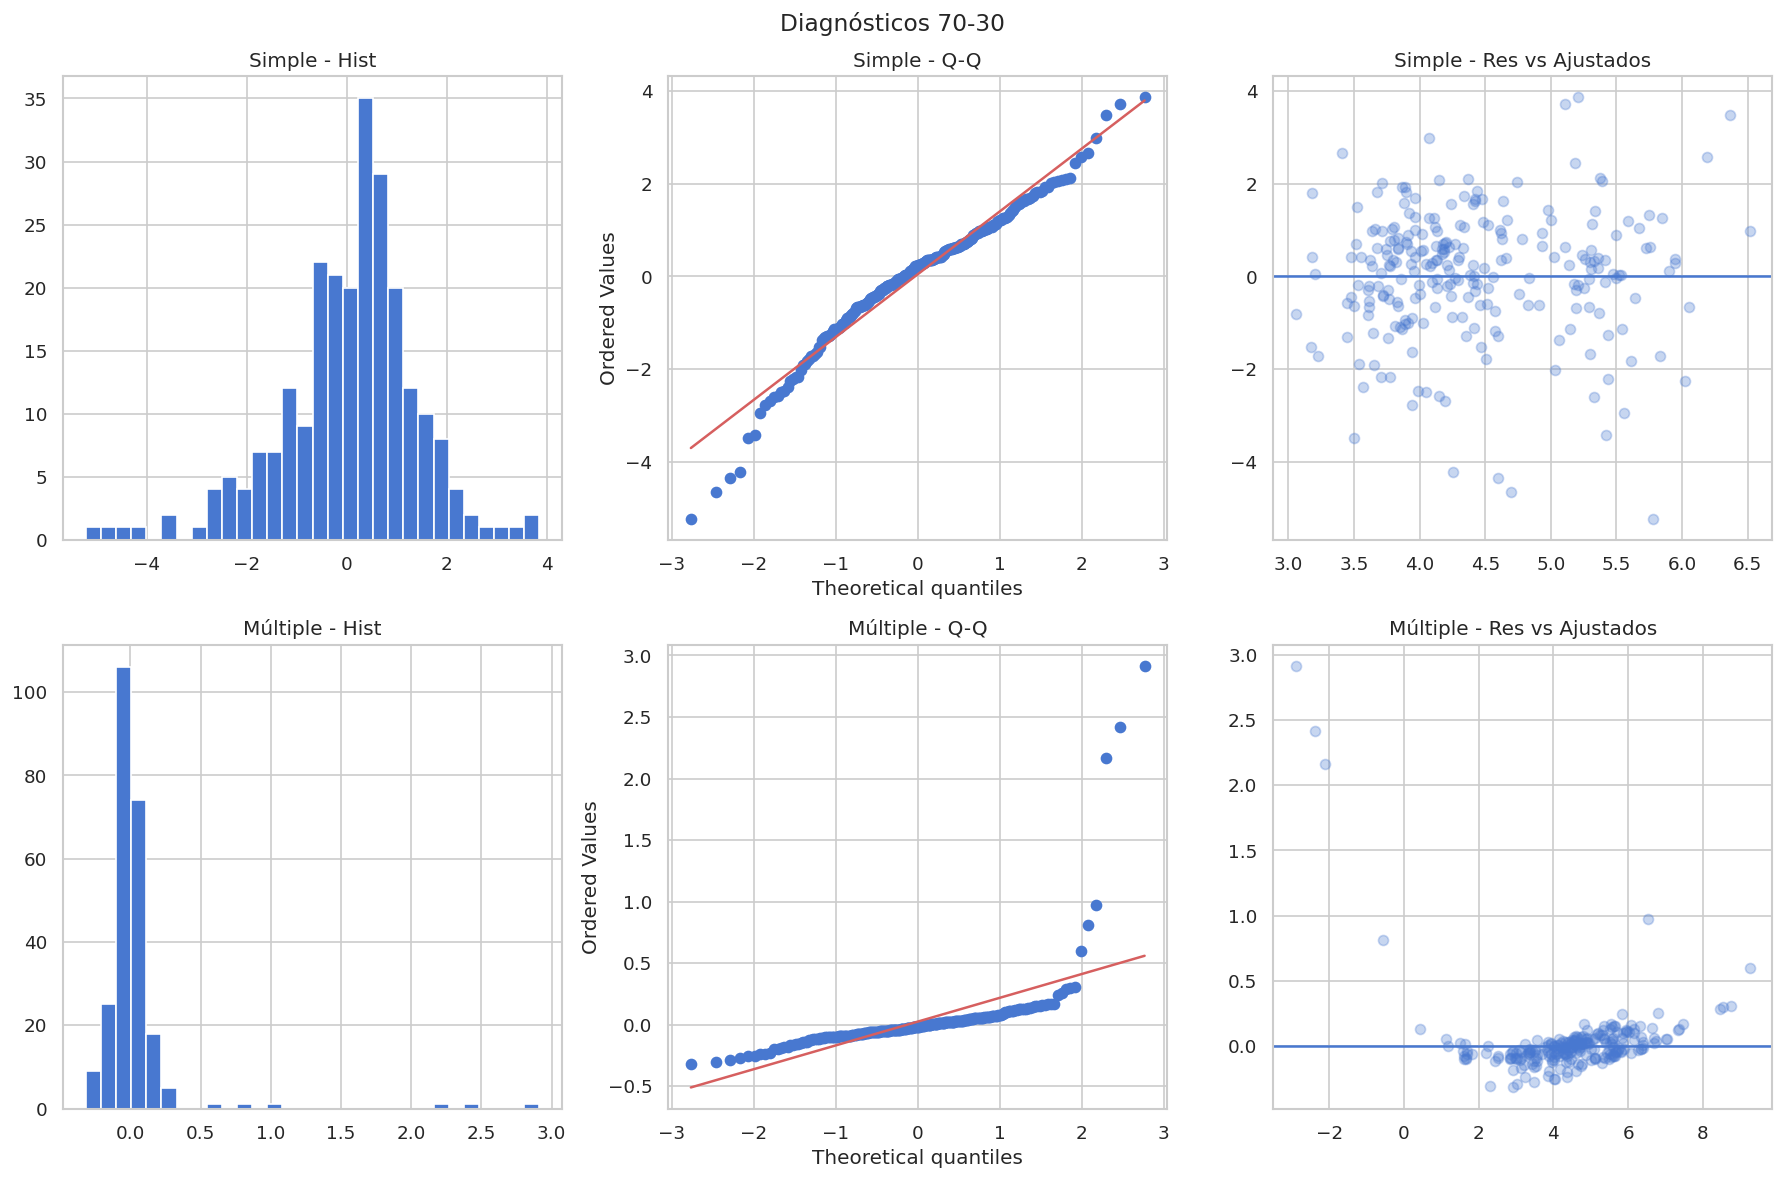

In [31]:
# ── CELDA 6: GRÁFICAS 70-30 ─────────────────

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- SIMPLE ---
y_pred_all_s70 = modelo_s70.predict(X_simple)
res_s70 = y - y_pred_all_s70

# --- MÚLTIPLE ---
y_pred_all_m70 = modelo_m70.predict(X_multi)
res_m70 = y - y_pred_all_m70

fig, axes = plt.subplots(2, 3, figsize=(15,10))
fig.suptitle("Diagnósticos 70-30", fontsize=14)

# SIMPLE
axes[0,0].hist(res_s70, bins=30)
axes[0,0].set_title("Simple - Hist")

stats.probplot(res_s70, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Simple - Q-Q")

axes[0,2].scatter(y_pred_all_s70, res_s70, alpha=0.3)
axes[0,2].axhline(0)
axes[0,2].set_title("Simple - Res vs Ajustados")

# MÚLTIPLE
axes[1,0].hist(res_m70, bins=30)
axes[1,0].set_title("Múltiple - Hist")

stats.probplot(res_m70, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Múltiple - Q-Q")

axes[1,2].scatter(y_pred_all_m70, res_m70, alpha=0.3)
axes[1,2].axhline(0)
axes[1,2].set_title("Múltiple - Res vs Ajustados")

plt.tight_layout()
plt.show()

In [32]:
# ── CELDA 3: SPLIT 60-40 (MÉTRICAS) ─────────────────

# Split
X_train_s60, X_test_s60, y_train_s60, y_test_s60 = train_test_split(
    X_simple, y, test_size=0.40, random_state=42
)

X_train_m60, X_test_m60, y_train_m60, y_test_m60 = train_test_split(
    X_multi, y, test_size=0.40, random_state=42
)

# Modelos
modelo_s60 = LinearRegression().fit(X_train_s60, y_train_s60)
modelo_m60 = LinearRegression().fit(X_train_m60, y_train_m60)

# Predicciones
y_pred_s60 = modelo_s60.predict(X_test_s60)
y_pred_m60 = modelo_m60.predict(X_test_m60)

# Métricas
r2_s60   = r2_score(y_test_s60, y_pred_s60)
rmse_s60 = np.sqrt(mean_squared_error(y_test_s60, y_pred_s60))
mae_s60  = mean_absolute_error(y_test_s60, y_pred_s60)

r2_m60   = r2_score(y_test_m60, y_pred_m60)
rmse_m60 = np.sqrt(mean_squared_error(y_test_m60, y_pred_m60))
mae_m60  = mean_absolute_error(y_test_m60, y_pred_m60)

print("\n📊 SPLIT 60-40")
print("="*40)
print("Modelo Simple:")
print(f"R²   : {r2_s60:.4f}")
print(f"RMSE : {rmse_s60:.4f}")
print(f"MAE  : {mae_s60:.4f}")

print("\nModelo Múltiple:")
print(f"R²   : {r2_m60:.4f}")
print(f"RMSE : {rmse_m60:.4f}")
print(f"MAE  : {mae_m60:.4f}")


📊 SPLIT 60-40
Modelo Simple:
R²   : 0.2918
RMSE : 1.3817
MAE  : 1.0174

Modelo Múltiple:
R²   : 0.9398
RMSE : 0.4028
MAE  : 0.1456


In [33]:
# ── CELDA 4: OLS 60-40 ─────────────────

# OLS Simple
X_ols_s60 = sm.add_constant(X_train_s60)
modelo_ols_s60 = sm.OLS(y_train_s60, X_ols_s60).fit()

# OLS Múltiple
X_ols_m60 = sm.add_constant(X_train_m60)
modelo_ols_m60 = sm.OLS(y_train_m60, X_ols_m60).fit()

print("\n📊 OLS 60-40 — SIMPLE")
print("="*50)
print(modelo_ols_s60.summary())

print("\n📊 OLS 60-40 — MÚLTIPLE")
print("="*50)
print(modelo_ols_m60.summary())


📊 OLS 60-40 — SIMPLE
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     31.91
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           8.44e-08
Time:                        12:04:29   Log-Likelihood:                -250.85
No. Observations:                 145   AIC:                             505.7
Df Residuals:                     143   BIC:                             511.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.3908      0.3

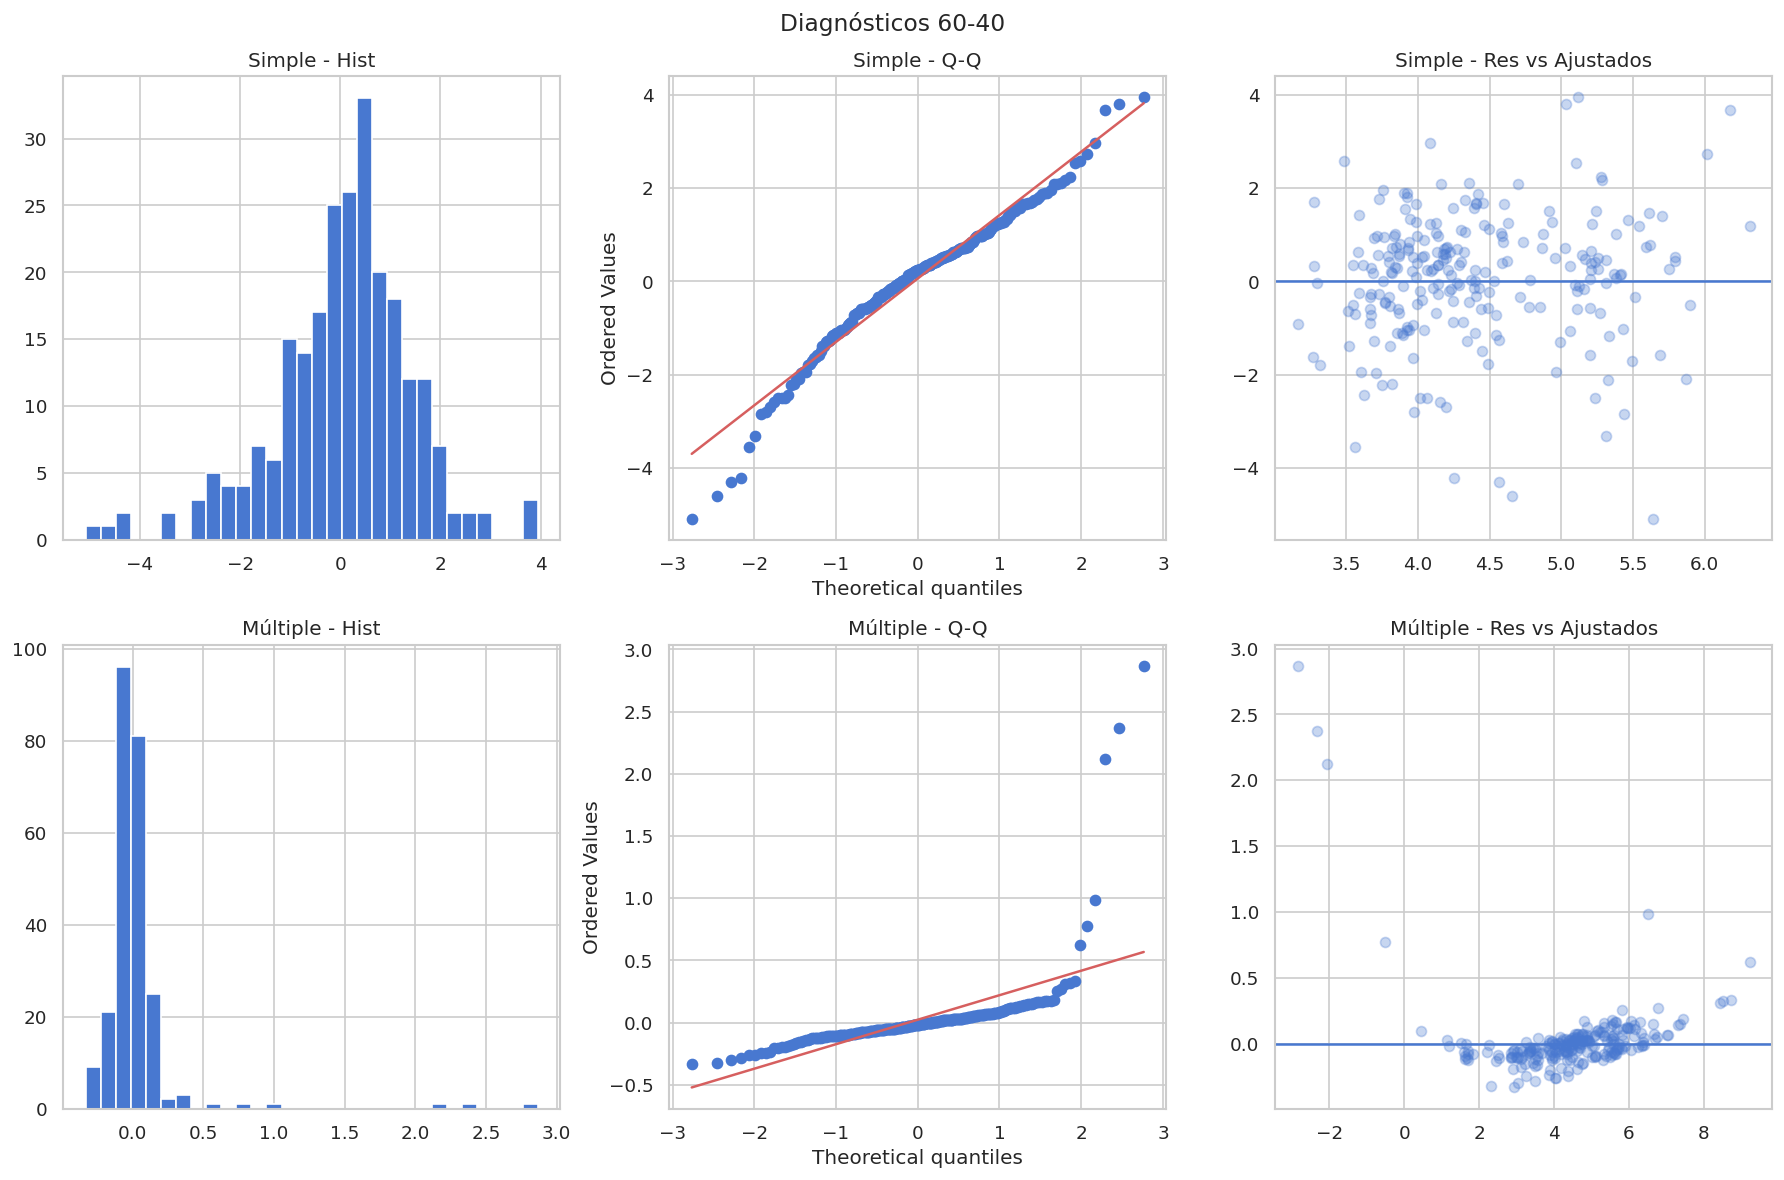

In [34]:
# ── CELDA 7: GRÁFICAS 60-40 ─────────────────

# --- SIMPLE ---
y_pred_all_s60 = modelo_s60.predict(X_simple)
res_s60 = y - y_pred_all_s60

# --- MÚLTIPLE ---
y_pred_all_m60 = modelo_m60.predict(X_multi)
res_m60 = y - y_pred_all_m60

fig, axes = plt.subplots(2, 3, figsize=(15,10))
fig.suptitle("Diagnósticos 60-40", fontsize=14)

# SIMPLE
axes[0,0].hist(res_s60, bins=30)
axes[0,0].set_title("Simple - Hist")

stats.probplot(res_s60, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Simple - Q-Q")

axes[0,2].scatter(y_pred_all_s60, res_s60, alpha=0.3)
axes[0,2].axhline(0)
axes[0,2].set_title("Simple - Res vs Ajustados")

# MÚLTIPLE
axes[1,0].hist(res_m60, bins=30)
axes[1,0].set_title("Múltiple - Hist")

stats.probplot(res_m60, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Múltiple - Q-Q")

axes[1,2].scatter(y_pred_all_m60, res_m60, alpha=0.3)
axes[1,2].axhline(0)
axes[1,2].set_title("Múltiple - Res vs Ajustados")

plt.tight_layout()
plt.show()

In [35]:
# ── CELDA 5: COMPARACIÓN FINAL ─────────────────

import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": [
        "Simple 70-30", "Múltiple 70-30",
        "Simple 60-40", "Múltiple 60-40"
    ],
    
    "R²": [
        r2_s70, r2_m70,
        r2_s60, r2_m60
    ],
    
    "RMSE": [
        rmse_s70, rmse_m70,
        rmse_s60, rmse_m60
    ],
    
    "MAE": [
        mae_s70, mae_m70,
        mae_s60, mae_m60
    ],
    
    "AIC": [
        modelo_ols_s70.aic, modelo_ols_m70.aic,
        modelo_ols_s60.aic, modelo_ols_m60.aic
    ],
    
    "BIC": [
        modelo_ols_s70.bic, modelo_ols_m70.bic,
        modelo_ols_s60.bic, modelo_ols_m60.bic
    ]
})

print("\n📊 COMPARACIÓN FINAL")
print("="*60)
print(comparacion.round(4).to_string(index=False))
print("="*60)

print("\n📌 AIC/BIC más bajo → mejor modelo")


📊 COMPARACIÓN FINAL
        Modelo     R²   RMSE    MAE      AIC      BIC
  Simple 70-30 0.2529 1.4565 1.0769 582.8034 589.0750
Múltiple 70-30 0.9223 0.4697 0.1698 -44.9776 -35.5702
  Simple 60-40 0.2918 1.3817 1.0174 505.6944 511.6479
Múltiple 60-40 0.9398 0.4028 0.1456 -18.7456  -9.8154

📌 AIC/BIC más bajo → mejor modelo


In [36]:
# ── CELDA FINAL: COMPARACIÓN TOTAL ─────────────────

import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": [
        "Simple 80-20", "Múltiple 80-20",
        "Simple 70-30", "Múltiple 70-30",
        "Simple 60-40", "Múltiple 60-40"
    ],
    
    "R²": [
        r2, r2_m,
        r2_s70, r2_m70,
        r2_s60, r2_m60
    ],
    
    "RMSE": [
        rmse, rmse_m,
        rmse_s70, rmse_m70,
        rmse_s60, rmse_m60
    ],
    
    "MAE": [
        mae, mae_m,
        mae_s70, mae_m70,
        mae_s60, mae_m60
    ],
    
    "AIC": [
        modelo_ols_simple.aic, modelo_ols_multi.aic,
        modelo_ols_s70.aic, modelo_ols_m70.aic,
        modelo_ols_s60.aic, modelo_ols_m60.aic
    ],
    
    "BIC": [
        modelo_ols_simple.bic, modelo_ols_multi.bic,
        modelo_ols_s70.bic, modelo_ols_m70.bic,
        modelo_ols_s60.bic, modelo_ols_m60.bic
    ]
})

print("\n📊 COMPARACIÓN FINAL COMPLETA")
print("="*70)
print(comparacion.round(4).to_string(index=False))
print("="*70)

print("\n📌 Claves:")
print("• Mayor R² → mejor explicación")
print("• Menor RMSE/MAE → menor error")
print("• Menor AIC/BIC → mejor modelo estadístico")


📊 COMPARACIÓN FINAL COMPLETA
        Modelo     R²   RMSE    MAE      AIC      BIC
  Simple 80-20 0.1512 1.3029 0.9975 845.2549 852.2410
Múltiple 80-20 0.9850 0.1730 0.1343 104.8317 115.3109
  Simple 70-30 0.2529 1.4565 1.0769 582.8034 589.0750
Múltiple 70-30 0.9223 0.4697 0.1698 -44.9776 -35.5702
  Simple 60-40 0.2918 1.3817 1.0174 505.6944 511.6479
Múltiple 60-40 0.9398 0.4028 0.1456 -18.7456  -9.8154

📌 Claves:
• Mayor R² → mejor explicación
• Menor RMSE/MAE → menor error
• Menor AIC/BIC → mejor modelo estadístico
